# Yamaguchi scattering example

This notebook shows how to use the spectral solver on the classic Yamaguchi non-local potential.

We will:

1. visualize the non-local kernel itself,
2. evaluate phase shifts on a fine energy grid from the spectrum,
3. compare the `l = 0` phase shift against the closed-form separable-model result,
4. show higher partial waves for context.


In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import lax as lm

HBAR2_2MU = 41.472
ALPHA = 0.2316053
BETA = 1.3918324


In [2]:
def yamaguchi_kernel(r1: jax.Array, r2: jax.Array) -> jax.Array:
    return -2.0 * BETA * (ALPHA + BETA) ** 2 * jnp.exp(-BETA * (r1 + r2)) * HBAR2_2MU


def yamaguchi_s_wave_analytic_phase_deg(energies_mev: np.ndarray) -> np.ndarray:
    k = np.sqrt(energies_mev / HBAR2_2MU)
    numerator = 2.0 * BETA * (ALPHA + BETA) ** 2 * k
    denominator = (BETA**2 + k**2) ** 2 - (ALPHA + BETA) ** 2 * (BETA**2 - k**2)
    return np.degrees(np.arctan2(numerator, denominator))


def unwrap_phase_shift_deg(phase_deg: np.ndarray) -> np.ndarray:
    return np.degrees(np.unwrap(2.0 * np.radians(phase_deg))) / 2.0


def yamaguchi_solver(angular_momentum: int, energies: jax.Array) -> lm.boundary._types.Solver:
    return lm.compile(
        mesh=lm.MeshSpec("legendre", "x", n=20, scale=15.0),
        channels=(lm.ChannelSpec(l=angular_momentum, threshold=0.0, mass_factor=HBAR2_2MU),),
        operators=("T+L",),
        solvers=("spectrum", "phases"),
        energies=energies,
    )


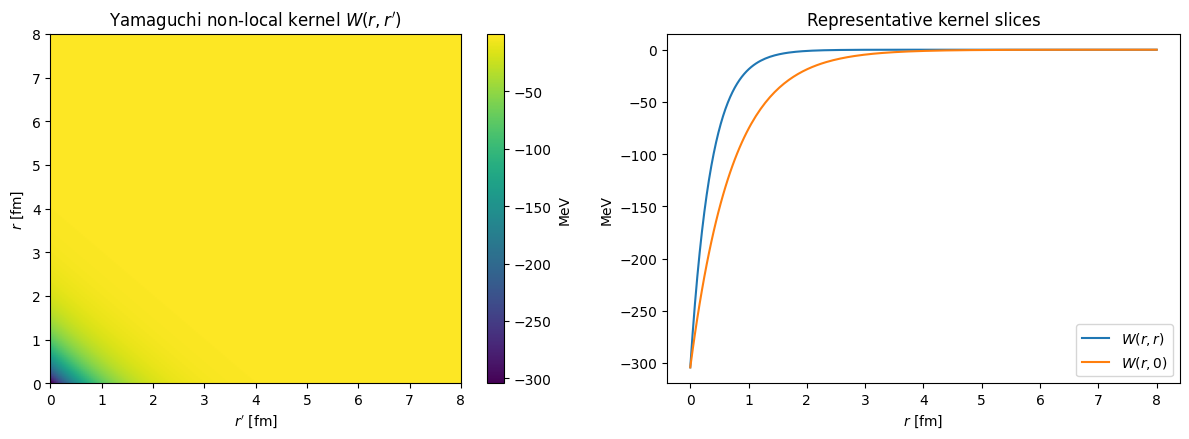

In [3]:
r_plot = np.linspace(0.0, 8.0, 200)
r1_grid, r2_grid = np.meshgrid(r_plot, r_plot, indexing="ij")
kernel_values = np.asarray(yamaguchi_kernel(jnp.asarray(r1_grid), jnp.asarray(r2_grid)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
image = axes[0].imshow(
    kernel_values,
    extent=[r_plot[0], r_plot[-1], r_plot[0], r_plot[-1]],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
axes[0].set_title("Yamaguchi non-local kernel $W(r, r')$")
axes[0].set_xlabel(r"$r'$ [fm]")
axes[0].set_ylabel(r"$r$ [fm]")
fig.colorbar(image, ax=axes[0], label="MeV")

axes[1].plot(r_plot, np.diag(kernel_values), label=r"$W(r, r)$")
axes[1].plot(r_plot, kernel_values[:, 0], label=r"$W(r, 0)$")
axes[1].set_title("Representative kernel slices")
axes[1].set_xlabel(r"$r$ [fm]")
axes[1].set_ylabel("MeV")
axes[1].legend()
fig.tight_layout()


In [7]:
energies = jnp.linspace(0.05, 10.0, 120)
partial_waves = [0, 1, 2]
phase_curves = {}

for angular_momentum in partial_waves:
    solver = yamaguchi_solver(angular_momentum, energies)
    potential = lm.assemble_nonlocal(solver.mesh, yamaguchi_kernel)
    spectrum = solver.spectrum(potential)
    principal_branch = np.asarray(solver.phases(spectrum)[:, 0]) * (180.0 / np.pi)
    phase_curves[angular_momentum] = unwrap_phase_shift_deg(principal_branch)

analytic_s_wave = yamaguchi_s_wave_analytic_phase_deg(np.asarray(energies))
max_s_wave_error = np.max(np.abs(phase_curves[0] - analytic_s_wave))
print(f"Maximum |δ_mesh - δ_analytic| for l=0 on this grid: {max_s_wave_error:.3e} degrees")


Maximum |δ_mesh - δ_analytic| for l=0 on this grid: 1.800e+02 degrees


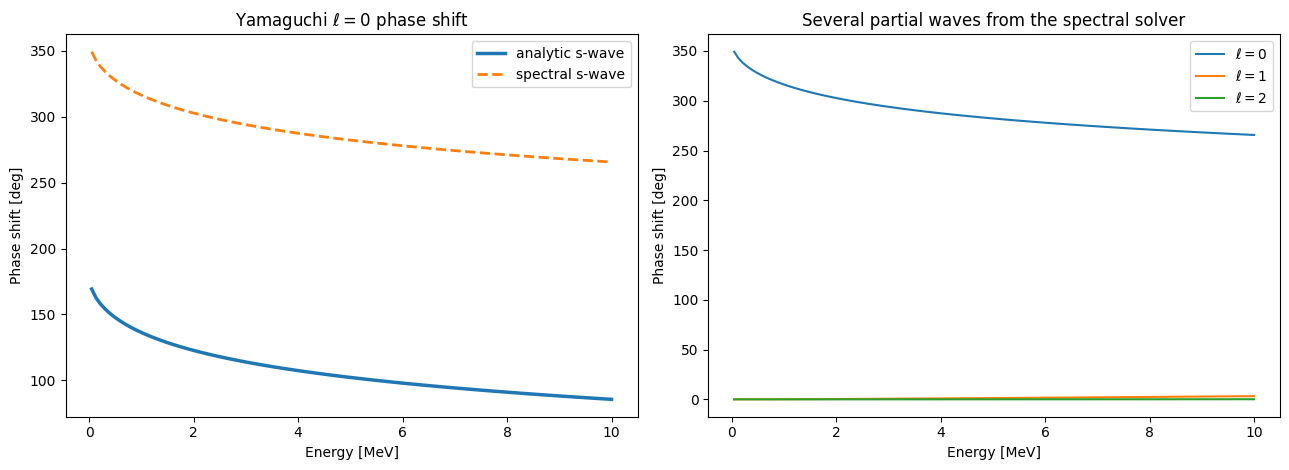

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

phase_curves[0] += 180
axes[0].plot(np.asarray(energies), analytic_s_wave, label="analytic s-wave", linewidth=2.5)
axes[0].plot(np.asarray(energies), phase_curves[0], "--", label="spectral s-wave", linewidth=2.0)
axes[0].set_title(r"Yamaguchi $\ell=0$ phase shift")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Phase shift [deg]")
axes[0].legend()

for angular_momentum in partial_waves:
    axes[1].plot(np.asarray(energies), phase_curves[angular_momentum], label=fr"$\ell={angular_momentum}$")
axes[1].set_title("Several partial waves from the spectral solver")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Phase shift [deg]")
axes[1].legend()
fig.tight_layout()


The Yamaguchi kernel is rank-one and separable, so the `l = 0` channel has a closed-form phase-shift curve. That makes it a good analytic check on the spectral solver. The phase shift is only defined modulo $180^\circ$, so the notebook unwraps $2\delta$ before plotting to remove branch-cut jumps that are numerical artifacts rather than physical discontinuities. The higher partial waves shown here are still useful numerically, even though the simplest closed-form comparison is the s-wave one.